In [1]:
from google.colab import files
uploaded = files.upload()

Saving prcp_day_MPI-ESM1-2-HR_ssp585.xlsx to prcp_day_MPI-ESM1-2-HR_ssp585.xlsx
Saving prcp_day_MPI-ESM1-2-HR_historical.xlsx to prcp_day_MPI-ESM1-2-HR_historical.xlsx
Saving prcp_day_MPI-ESM1-2-HR_ssp245.xlsx to prcp_day_MPI-ESM1-2-HR_ssp245.xlsx


In [43]:
from google.colab import files
uploaded = files.upload()

Saving Sendafa_prcp_Processed.xlsx to Sendafa_prcp_Processed.xlsx


Section One

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def run_multiplicative_qdm(obs_vals, gcm_h_vals, gcm_f_vals):
    """
    QDM Algorithm for Precipitation (Multiplicative)
    Preserves the relative climate change signal and zero-rain days.
    """
    # 1. Basic Cleaning
    obs_vals = obs_vals[~np.isnan(obs_vals)]
    gcm_h_vals = gcm_h_vals[~np.isnan(gcm_h_vals)]
    gcm_f_vals = gcm_f_vals[~np.isnan(gcm_f_vals)]

    # 2. Calculate empirical quantiles for future GCM data (tau_n)
    n = len(gcm_f_vals)
    ranks = pd.Series(gcm_f_vals).rank(method='average')
    tau_n = np.clip((ranks - 0.5) / n, 0, 1)

    # 3. Calculate historical GCM and Obs values at matching quantiles
    gcm_h_q = np.quantile(gcm_h_vals, tau_n)
    obs_h_q = np.quantile(obs_vals, tau_n)

    # 4. Calculate Model Trend (Multiplicative Ratio)
    # Use a small epsilon (0.0001) to avoid division by zero on dry days
    gcm_ratio = np.where(gcm_h_q > 0.01, gcm_f_vals / gcm_h_q, 1.0)

    # 5. Result = Station Reality * Projected GCM Ratio
    result = obs_h_q * gcm_ratio

    # Ensure no negative values
    return np.maximum(result, 0)

Section 2

In [44]:
# 1. Load Files (Change file names for each station)
station_name = "Sendafa"
df_obs = pd.read_excel('Sendafa_prcp_Processed.xlsx', header=None, names=['P'])
df_gcm_h = pd.read_excel('prcp_day_MPI-ESM1-2-HR_historical.xlsx', header=None, names=['P'])
df_gcm_f_245 = pd.read_excel('prcp_day_MPI-ESM1-2-HR_ssp245.xlsx', header=None, names=['P'])
df_gcm_f_585 = pd.read_excel('prcp_day_MPI-ESM1-2-HR_ssp585.xlsx', header=None, names=['P'])

# 2. Assign Date ranges (Match your specific study years)
df_obs.index = pd.date_range(start='1985-01-01', periods=len(df_obs), freq='D')
df_gcm_h.index = pd.date_range(start='1985-01-01', periods=len(df_gcm_h), freq='D')
df_gcm_f_245.index = pd.date_range(start='2015-01-01', periods=len(df_gcm_f_245), freq='D')
df_gcm_f_585.index = pd.date_range(start='2015-01-01', periods=len(df_gcm_f_585), freq='D')

# 3. Align Calendars (Remove Feb 29 from Obs if GCM uses 365-day calendar)
if len(df_obs) != len(df_gcm_h):
    df_obs = df_obs[~((df_obs.index.month == 2) & (df_obs.index.day == 29))]
    df_gcm_h = df_gcm_h[~((df_gcm_h.index.month == 2) & (df_gcm_h.index.day == 29))]

print(f"Data sync complete for {station_name}. Daily records: {len(df_obs)}")

Data sync complete for Sendafa. Daily records: 10957


Section 3

In [45]:
# Run the QDM math
qdm_245 = run_multiplicative_qdm(df_obs['P'].values, df_gcm_h['P'].values, df_gcm_f_245['P'].values)
qdm_585 = run_multiplicative_qdm(df_obs['P'].values, df_gcm_h['P'].values, df_gcm_f_585['P'].values)

results_245 = pd.DataFrame({'P_QDM': qdm_245}, index=df_gcm_f_245.index)
results_585 = pd.DataFrame({'P_QDM': qdm_585}, index=df_gcm_f_585.index)

def analyze_precip_terms(df, baseline_mean, label):
    terms = {
        "Near-term (2021-2050)": ('2021-01-01', '2050-12-31'),
        "Mid-term (2051-2080)":  ('2051-01-01', '2080-12-31'),
        "Long-term (2081-2100)": ('2081-01-01', '2100-12-31')
    }
    print(f"\n--- {label} Precipitation Impact Analysis ---")
    for name, (start, end) in terms.items():
        term_mean = df.loc[start:end, 'P_QDM'].mean()
        perc_change = ((term_mean - baseline_mean) / baseline_mean) * 100
        print(f"{name}: {term_mean:.4f} mm/day (Change: {perc_change:+.2f} %)")

h_mean_p = df_obs['P'].mean()
analyze_precip_terms(results_245, h_mean_p, "SSP245")
analyze_precip_terms(results_585, h_mean_p, "SSP585")


--- SSP245 Precipitation Impact Analysis ---
Near-term (2021-2050): 3.4178 mm/day (Change: +7.12 %)
Mid-term (2051-2080): 3.4507 mm/day (Change: +8.15 %)
Long-term (2081-2100): 3.3121 mm/day (Change: +3.81 %)

--- SSP585 Precipitation Impact Analysis ---
Near-term (2021-2050): 3.0240 mm/day (Change: -5.22 %)
Mid-term (2051-2080): 3.6723 mm/day (Change: +15.10 %)
Long-term (2081-2100): 4.0586 mm/day (Change: +27.20 %)




Secton 4



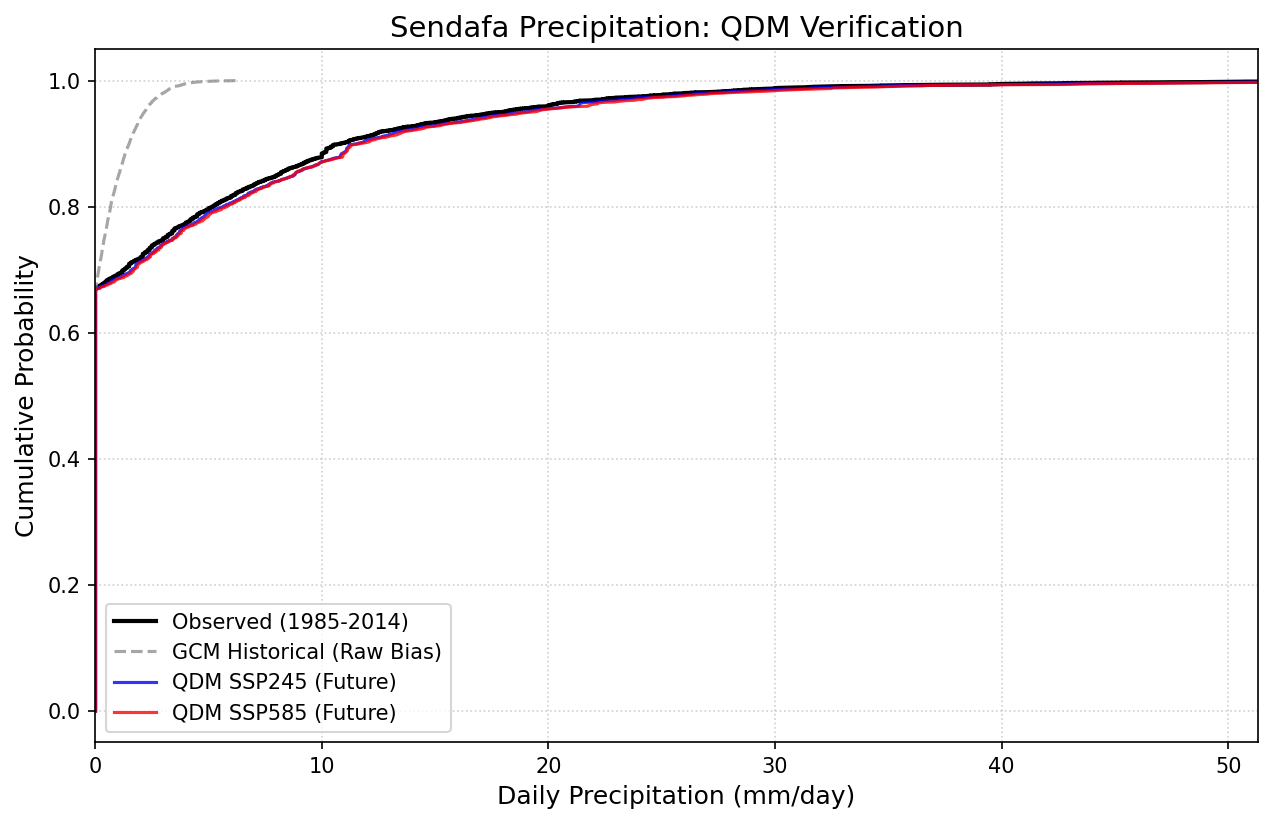

In [46]:
plt.figure(figsize=(10, 6), dpi=150)

# Sort for CDF
obs_s = np.sort(df_obs['P'])
gcm_h_s = np.sort(df_gcm_h['P'])
s245_s = np.sort(results_245['P_QDM'])
s585_s = np.sort(results_585['P_QDM'])

# Probabilities
prob_h = np.linspace(0, 1, len(obs_s))
prob_f = np.linspace(0, 1, len(s245_s))

# Plot lines
plt.plot(obs_s, prob_h, label='Observed (1985-2014)', color='black', linewidth=2)
plt.plot(gcm_h_s, prob_h, label='GCM Historical (Raw Bias)', color='gray', linestyle='--', alpha=0.7)
plt.plot(s245_s, prob_f, label='QDM SSP245 (Future)', color='blue', alpha=0.8)
plt.plot(s585_s, prob_f, label='QDM SSP585 (Future)', color='red', alpha=0.8)

# Focus on the 'Wet' part of the curve (ignore the 0mm days for better visibility)
plt.xlim(0, obs_s.max() * 0.5)
plt.title(f"{station_name} Precipitation: QDM Verification", fontsize=14)
plt.xlabel("Daily Precipitation (mm/day)", fontsize=12)
plt.ylabel("Cumulative Probability", fontsize=12)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.savefig(f"{station_name}_Precip_QDM_Plot.png")
plt.show()

In [47]:
results_245.to_excel(f"{station_name}_P_SSP245_QDM.xlsx", header=False)
results_585.to_excel(f"{station_name}_P_SSP585_QDM.xlsx", header=False)
print(f"Results saved for {station_name}")

Results saved for Sendafa
